# Model Training Notebook

This notebook trains and evaluates our freight pricing model.

## What we do in this notebook
- Load the processed pricing dataset produced in the data cleaning notebook.
- Filter the training data to dry goods only, because the current product focuses on dry freight.
- Prepare the feature matrix and target price for model training.
- Train and compare multiple regression methods.
- Run a hyperparameter search for the XGBoost model.
- Evaluate the model with MAE, MAPE, R², and median absolute error.
- Inspect feature correlations to understand what drives price.
- Test the trained model against a small Australian benchmark sample.

## Why we chose XGBoost
We selected XGBoost as the main model because it is a strong tabular-data baseline, handles nonlinear relationships well, and usually performs better than simple linear models on pricing problems. It also gives us a good balance between accuracy, robustness, and training speed.

## What we learned from the experiments
We trained XGBoost with a hyperparameter search and compared it against Linear Regression, Random Forest, and a Simple Neural Network.

The XGBoost model achieved the best results on the internal holdout set:
- R² score: 0.9666
- MAPE: 0.0889
- RMSE: 624.9662
- Median Absolute Error: 312.5992

The comparison models performed worse:
- Random Forest: MAE 475.25, RMSE: 678.603294, MAPE 0.0915, R² 0.9606
- Simple Neural Network: MAE 893.80, RMSE: 1260.285804, MAPE 0.1662, R² 0.8642
- Linear Regression: MAE 899.20, RMSE: 1263.507916, MAPE 0.1680, R² 0.8635

## Correlation analysis
We also looked at how strongly the features correlate with the target price. That analysis showed that the model is heavily driven by distance and duration, which explains why the internal test metrics are so strong. In other words, the dataset is informative, but it also means the model may rely too much on route length as the main pricing signal.

## Australian market calibration
Because no large public Australian freight pricing dataset was available, we used an American route-freight dataset as the base training data and then adapted it to the Australian market.

In the earlier notebook we:
- cleaned and aggregated the raw tables so each row represents one load
- converted pounds, miles, gallons, and USD-based values into Australian units and AUD
- adjusted for Australian operating costs, fuel cost differences, and market pricing assumptions
- filtered the base training data to dry goods only

To check how well the model transfers, we tested it on a small Australian FTL benchmark sample from Couriers and Freight:
https://www.couriersandfreight.com.au/blog/current-full-truck-load-rates

That Australian sample behaved very differently from the American training data:
- MAE: AUD 1766.24
- RMSE: AUD 3112.42
- MAPE: 57.12%
- R²: -0.465

This suggests a clear domain shift. The Australian sample is much noisier and likely reflects additional real-world pricing effects such as urgency, negotiation, empty return legs, special handling, and low-competition routes. It is also important that the Australian benchmark contains many different load types, while our American training data was filtered specifically for dry goods.

## Interpretation
The strong internal results are useful, but they should not be over-interpreted. R² is a good metric because it shows how much of the variation in price the model explains, and it helps detect when the model stops generalizing across markets. But for freight pricing we also care about MAE, RMSE, and MAPE, because they tell us how far off the price is in dollars and in percentage terms.

## Next step
We use this model as a base model and plan to fine-tune or retrain it later with Australian platform data once enough local examples are available.

In [10]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_percentage_error,
    median_absolute_error,
)


In [11]:
df = pd.read_csv("processed_datasets/pricing_training_table.csv")

target = "revenue_aud"

# remove the all the rows where the load_type is Refrigerated
df = df[df["load_type"] != "Refrigerated"]
# fuel_surcharge_rate,actual_duration_hours,weight_kg,distance_km,fuel_quantity_liters,avg_fuel_price_aud_per_liter,total_fuel_cost_aud,revenue_aud,fuel_surcharge_aud,base_rate_per_km_aud
drop_cols = [
    target,
    "load_type",
    "origin_city",
    "destination_city",
    "lane",
    "base_rate_per_mile",
    "pieces",
    "fuel_surcharge",
    "total_fuel_quantity",
    "annual_revenue_potential_aud",
    "primary_freight_type",
]


drop_cols.extend(
    [
        "fuel_surcharge_rate",
        "fuel_quantity_liters",
        "avg_fuel_price_aud_per_liter",
        "total_fuel_cost_aud",
        "fuel_surcharge_aud",
        "base_rate_per_km_aud",
    ]
)


feature_cols = [c for c in df.columns if c not in drop_cols]

print("Features:", feature_cols)

X = df[feature_cols].copy()
y = df[target].copy()


# datetime-Spalten raus
for c in X.columns:
    if str(X[c].dtype).startswith("datetime"):
        X = X.drop(columns=[c])

# categorical -> category codes
for c in X.columns:
    if X[c].dtype == "string" or X[c].dtype == "object":
        X[c] = X[c].astype("category")

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].cat.codes.replace(-1, np.nan)

# simple fillna
for c in X.columns:
    if X[c].dtype.kind in "biufc":
        X[c] = X[c].fillna(X[c].median())
    else:
        X[c] = X[c].fillna("missing")

Features: ['actual_duration_hours', 'weight_kg', 'distance_km']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Initialize the base model
base_model = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Define the grid of parameters you want to test
param_distributions = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [3, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

# 3. Set up the randomized search
# n_iter=20 means it will randomly test 20 different combinations.
# cv=3 means 3-fold cross-validation (helps prevent overfitting).
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",  # We want to minimize MAE
    cv=3,
    verbose=1,  # Prints the progress in your console
    random_state=42,
    n_jobs=-1,
)

print("Starting hyperparameter tuning...")

# 4. Fit the search on the training data
search.fit(X_train, y_train)

# 5. Print the winning combination
print("\nBest parameters found:")
print(search.best_params_)

# 6. Extract the best model from the search
best_model = search.best_estimator_

# 7. Evaluate the winning model on your holdout test set
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\n--- Final Test Set Performance ---")
print("MAE:", mae)
print("RMSE:", rmse)

# 8. Save the best model to disk for your backend
best_model.save_model("xgboost_pricing_model.json")
print("\nSuccess: Best model saved as 'xgboost_pricing_model.json'")

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found:
{'subsample': 0.6, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

--- Final Test Set Performance ---
MAE: 448.9813031807732
RMSE: 624.9662376502034

Success: Best model saved as 'xgboost_pricing_model.json'


R2 Score: 0.9666
MAPE: 0.0889
Median Absolute Error: 312.5992
RMSE: 624.9662


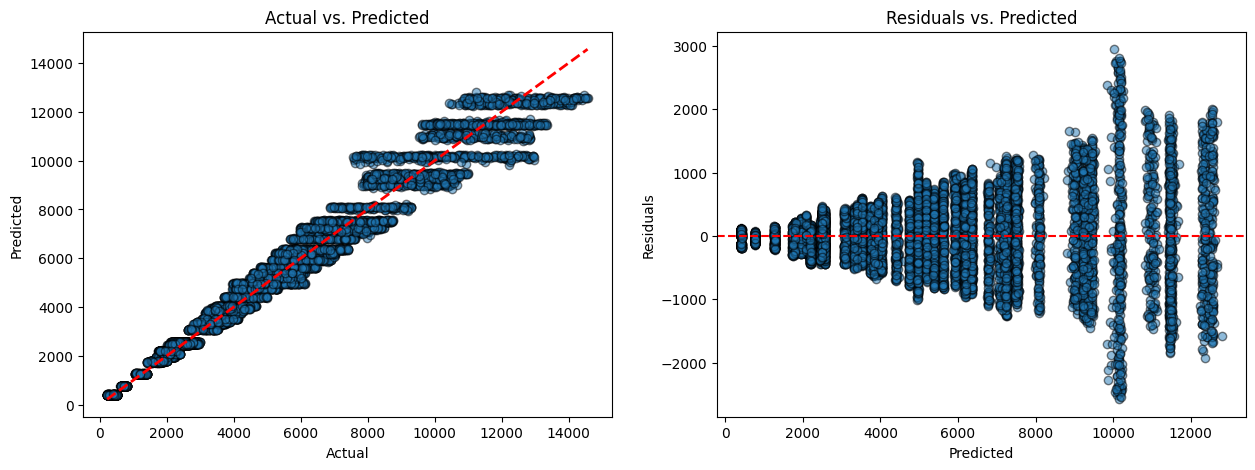

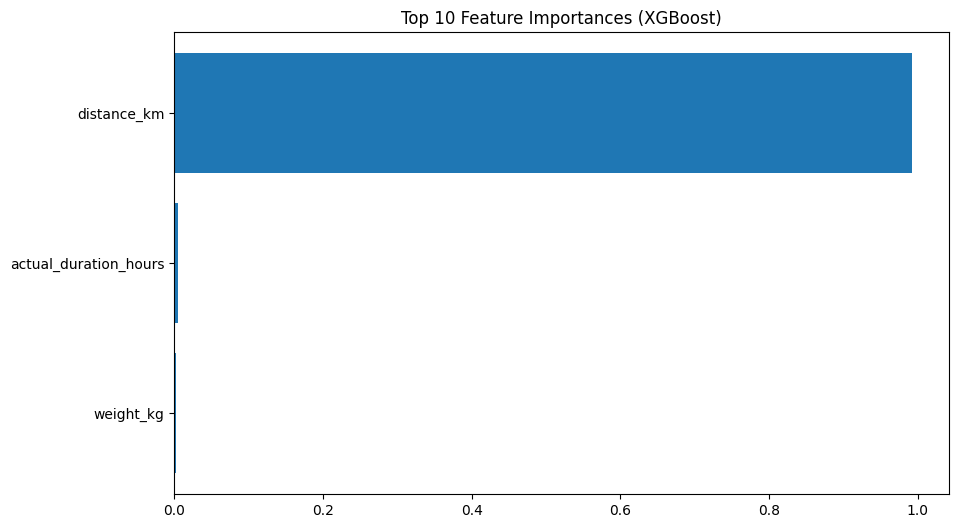

In [13]:
# 1. Calculate Additional Metrics
r2 = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
medae = median_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median Absolute Error: {medae:.4f}")
print(f"RMSE: {rmse:.4f}")

# 2. Visualizing Performance
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
ax[0].scatter(y_test, pred, alpha=0.5, edgecolors="k")
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax[0].set_title("Actual vs. Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

# Residual Plot
residuals = y_test - pred
ax[1].scatter(pred, residuals, alpha=0.5, edgecolors="k")
ax[1].axhline(0, color="r", linestyle="--")
ax[1].set_title("Residuals vs. Predicted")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Residuals")

plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

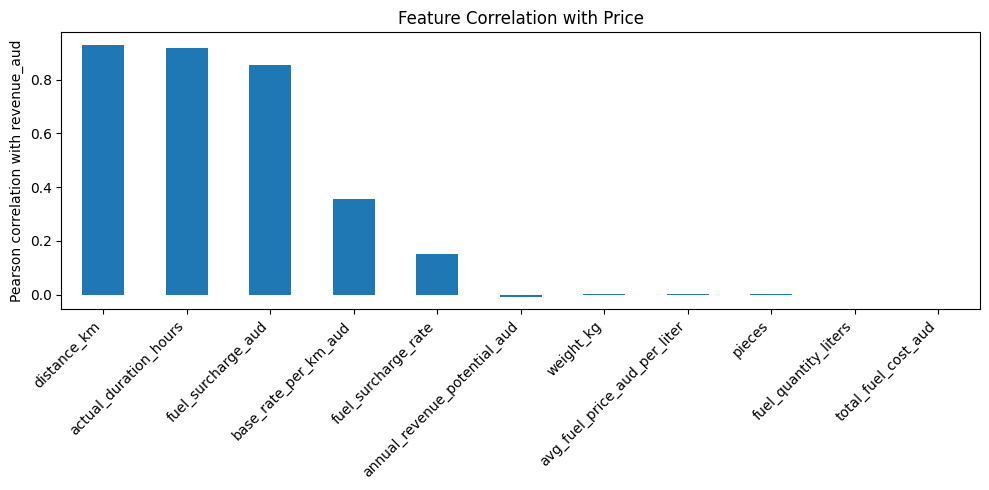

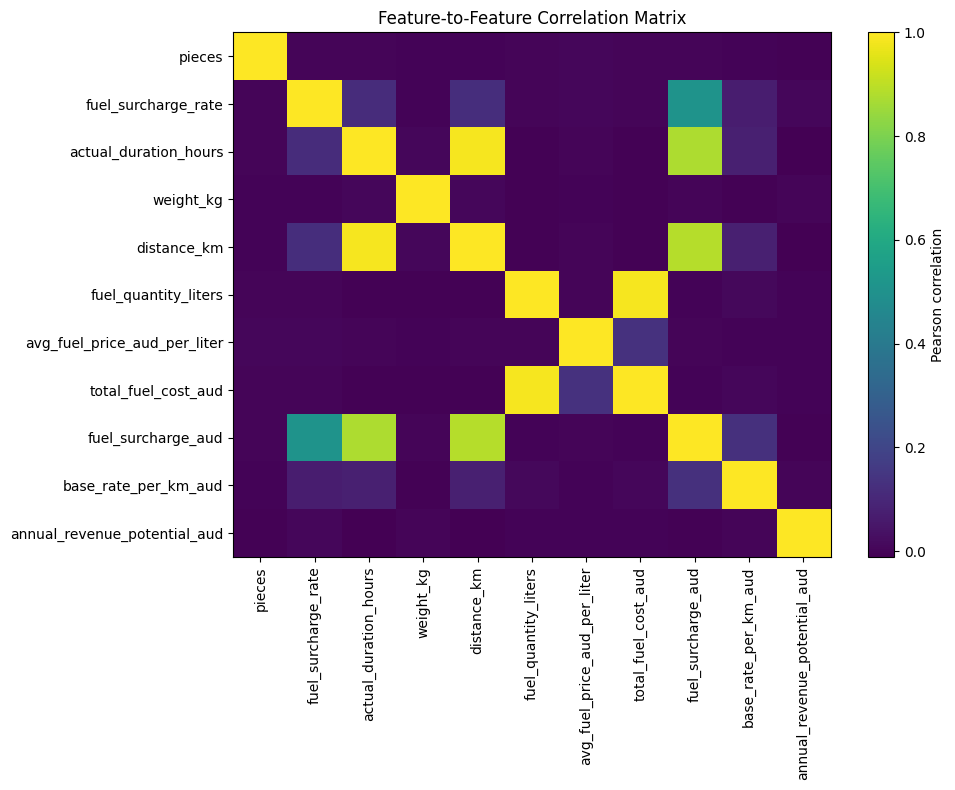

In [14]:
# df = your dataframe
target = "revenue_aud"

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# -----------------------------
# 1) Correlation: features vs price
# -----------------------------
price_corr = (
    df[numeric_cols]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 5))
price_corr.plot(kind="bar")
plt.title("Feature Correlation with Price")
plt.ylabel("Pearson correlation with revenue_aud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Correlation: features with each other
# -----------------------------
feature_corr = df[numeric_cols].drop(columns=[target]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=90)
plt.yticks(range(len(feature_corr.columns)), feature_corr.columns)
plt.title("Feature-to-Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "Simple Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32), activation="relu", max_iter=1000, random_state=42
    ),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = mean_absolute_percentage_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2})

results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df)

Training Linear Regression...
Training Random Forest...
Training Simple Neural Network...
                   model         MAE         RMSE      MAPE        R2
1          Random Forest  475.254259   678.603294  0.091547  0.960627
2  Simple Neural Network  893.798363  1260.285804  0.166220  0.864198
0      Linear Regression  899.201627  1263.507916  0.167967  0.863503


In [16]:
# From here: https://www.couriersandfreight.com.au/blog/current-full-truck-load-rates

# -----------------------------
# Australian FTL benchmark sample
# -----------------------------
australian_freight_samples = [
    {"distance_km": 920, "weight_kg": 22000, "revenue_aud": 2520},
    {"distance_km": 880, "weight_kg": 22000, "revenue_aud": 1470},
    {"distance_km": 1410, "weight_kg": 22000, "revenue_aud": 2500},
    {"distance_km": 3935, "weight_kg": 22000, "revenue_aud": 9450},
    {"distance_km": 1600, "weight_kg": 22000, "revenue_aud": 2700},
    {"distance_km": 920, "weight_kg": 22000, "revenue_aud": 1417.50},
    {"distance_km": 1680, "weight_kg": 22000, "revenue_aud": 2310},
    {"distance_km": 2000, "weight_kg": 22000, "revenue_aud": 3000},
    {"distance_km": 4310, "weight_kg": 22000, "revenue_aud": 9975},
    {"distance_km": 880, "weight_kg": 22000, "revenue_aud": 1995},
    {"distance_km": 1680, "weight_kg": 22000, "revenue_aud": 4200},
    {"distance_km": 730, "weight_kg": 22000, "revenue_aud": 1879.50},
    {"distance_km": 3420, "weight_kg": 22000, "revenue_aud": 8925},
    {"distance_km": 1000, "weight_kg": 22000, "revenue_aud": 2310},
    {"distance_km": 830, "weight_kg": 22000, "revenue_aud": 1950},
    {"distance_km": 1410, "weight_kg": 22000, "revenue_aud": 2520},
    {"distance_km": 2000, "weight_kg": 22000, "revenue_aud": 3725},
    {"distance_km": 730, "weight_kg": 22000, "revenue_aud": 997.50},
    {"distance_km": 2695, "weight_kg": 22000, "revenue_aud": 7140},
    {"distance_km": 3935, "weight_kg": 22000, "revenue_aud": 3150},
    {"distance_km": 4310, "weight_kg": 22000, "revenue_aud": 4462.50},
    {"distance_km": 3420, "weight_kg": 22000, "revenue_aud": 2940},
    {"distance_km": 2695, "weight_kg": 22000, "revenue_aud": 2100},
]

# Add estimated actual durations (hours).
# These are estimated using an 80 km/h average truck speed as a practical lookup substitute
for s in australian_freight_samples:
    s['actual_duration_hours'] = round(s['distance_km'] / 80, 2)

aus_df = pd.DataFrame(australian_freight_samples)

X_aus = aus_df[["actual_duration_hours", "weight_kg", "distance_km"]]
y_aus = aus_df["revenue_aud"]

# -----------------------------
# Predict
# -----------------------------
australian_predictions = best_model.predict(X_aus)

# -----------------------------
# Metrics
# -----------------------------
mae = mean_absolute_error(y_aus, australian_predictions)
rmse = np.sqrt(mean_squared_error(y_aus, australian_predictions))
mape = np.mean(np.abs((y_aus - australian_predictions) / y_aus)) * 100
r2 = r2_score(y_aus, australian_predictions)

print("\n--- Australian FTL Benchmark Performance ---")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Individual predictions
# -----------------------------
aus_df["predicted_revenue_aud"] = australian_predictions
aus_df["absolute_error_aud"] = np.abs(
    aus_df["revenue_aud"] - aus_df["predicted_revenue_aud"]
)
aus_df["percentage_error"] = aus_df["absolute_error_aud"] / aus_df["revenue_aud"] * 100

print("\n--- Individual Predictions ---")
print(aus_df)


--- Australian FTL Benchmark Performance ---
MAE:  $1766.24
RMSE: $3112.42
MAPE: 57.12%
R²:   -0.465

--- Individual Predictions ---
    distance_km  weight_kg  revenue_aud  actual_duration_hours  \
0           920      22000       2520.0                  11.50   
1           880      22000       1470.0                  11.00   
2          1410      22000       2500.0                  17.62   
3          3935      22000       9450.0                  49.19   
4          1600      22000       2700.0                  20.00   
5           920      22000       1417.5                  11.50   
6          1680      22000       2310.0                  21.00   
7          2000      22000       3000.0                  25.00   
8          4310      22000       9975.0                  53.88   
9           880      22000       1995.0                  11.00   
10         1680      22000       4200.0                  21.00   
11          730      22000       1879.5                   9.12   
12      